In [5]:
from google.colab import files
uploaded = files.upload()

Saving all_month.csv to all_month.csv


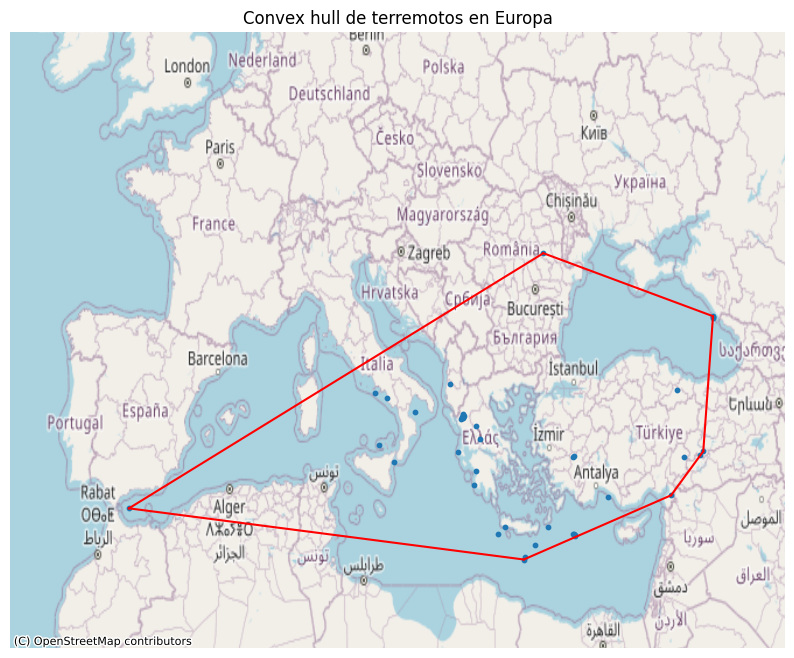

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import geopandas as gpd
import contextily as ctx
import numpy as np

df = pd.read_csv("all_month.csv")

df = df[(df["longitude"] > -20) & (df["longitude"] < 40) &
        (df["latitude"] > 30) & (df["latitude"] < 70) &
        (df["mag"] > 4)]

gdf = gpd.GeoDataFrame(df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326").to_crs(epsg=3857)

points = [[p.x, p.y] for p in gdf.geometry]

hull = ConvexHull(points)

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(*zip(*points), s=10)

for s in hull.simplices:
    ax.plot([points[s[0]][0], points[s[1]][0]],
            [points[s[0]][1], points[s[1]][1]], 'r-')

ctx.add_basemap(ax)

ax.set_xlim(-1.5e6, 5e6)
ax.set_ylim(3.5e6, 7e6)
ax.set_title("Convex hull de terremotos en Europa")
ax.set_axis_off()

plt.show()